In [39]:
#A test notebook for sorting out api data aquisition

In [40]:
import sys
print(sys.executable)

/home/djmead/Documents/Projects/Financial/.venv/bin/python


In [41]:
from fredapi import Fred
import pandas as pd
#import os
import keyring#, getpass
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
service = "fred"
api_key = keyring.get_password(service, "api_key")
#api_secret = keyring.get_password(service, "ALPACA_SECRET_KEY")

print(f"API Key: {api_key[:3]}")

API Key: b7b


In [43]:
fred = Fred(api_key=api_key)
unemployment_data = fred.get_series('UNRATE', observation_start='2023-01-01', observation_end='2026-07-31')
print("--- Unemployment Rate Series ---")
print(unemployment_data.tail(24))

--- Unemployment Rate Series ---
2024-08-01    4.2
2024-09-01    4.1
2024-10-01    4.1
2024-11-01    4.2
2024-12-01    4.1
2025-01-01    4.0
2025-02-01    4.2
2025-03-01    4.2
2025-04-01    4.2
2025-05-01    4.3
2025-06-01    4.1
2025-07-01    4.3
2025-08-01    4.3
2025-09-01    4.4
2025-10-01    NaN
2025-11-01    4.5
2025-12-01    4.4
2026-01-01    4.3
2026-02-01    4.4
2026-03-01    4.3
2026-04-01    4.3
2026-05-01    4.3
2026-06-01    4.2
2026-07-01    4.1
dtype: float64


In [44]:
gdp = fred.get_series('GDPC1', observation_start='2023-01-01')
cpi = fred.get_series('CPIAUCSL', observation_start='2023-01-01')
economic_df = pd.DataFrame({'Real_GDP': gdp, 'CPI': cpi})
print("\n--- Combined Economic DataFrame ---")
print(economic_df)#.tail())


--- Combined Economic DataFrame ---
             Real_GDP      CPI
2023-01-01  22439.607  300.420
2023-02-01        NaN  301.450
2023-03-01        NaN  301.821
2023-04-01  22580.499  302.845
2023-05-01        NaN  303.334
2023-06-01        NaN  304.014
2023-07-01  22840.989  304.609
2023-08-01        NaN  306.082
2023-09-01        NaN  307.276
2023-10-01  23033.780  307.696
2023-11-01        NaN  308.148
2023-12-01        NaN  308.741
2024-01-01  23082.119  309.698
2024-02-01        NaN  310.967
2024-03-01        NaN  312.345
2024-04-01  23286.508  313.023
2024-05-01        NaN  313.175
2024-06-01        NaN  313.044
2024-07-01  23478.570  313.569
2024-08-01        NaN  314.062
2024-09-01        NaN  314.732
2024-10-01  23586.542  315.631
2024-11-01        NaN  316.528
2024-12-01        NaN  317.604
2025-01-01  23548.210  318.961
2025-02-01        NaN  319.679
2025-03-01        NaN  319.785
2025-04-01  23770.976  320.302
2025-05-01        NaN  320.620
2025-06-01        NaN  321.435
20

In [45]:
# 3. Search for a specific data series ID code
search_results = fred.search('inflation')
print("\n--- Search Results for 'inflation' ---")
print(search_results[['title', 'units']].head())


--- Search Results for 'inflation' ---
                                                             title    units
series id                                                                  
DFII10           Market Yield on U.S. Treasury Securities at 10...  Percent
FII10            Market Yield on U.S. Treasury Securities at 10...  Percent
WFII10           Market Yield on U.S. Treasury Securities at 10...  Percent
RIFLGFCY10XIINA  Market Yield on U.S. Treasury Securities at 10...  Percent
T10YIE                            10-Year Breakeven Inflation Rate  Percent


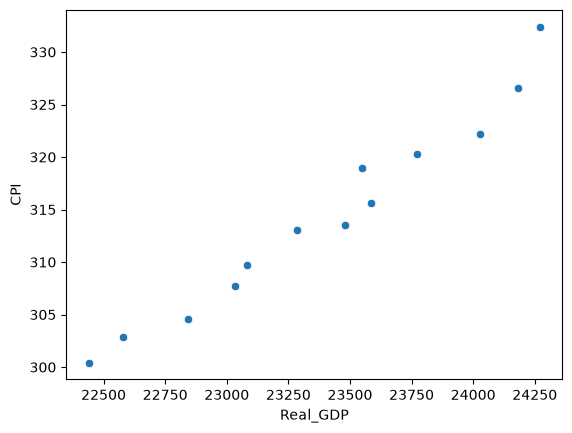

In [46]:
sns.scatterplot(data=economic_df, x='Real_GDP', y='CPI')
plt.show()

In [47]:
fred_ids = []
with open("../documentation/fred_ids.txt", "r") as file:
    fred_ids = [line.strip() for line in file.readlines()]
for id in fred_ids:print(id)

#with open("assets_us_equity.json", "w") as f:
#    json.dump(resp_json, f, indent=4)

DEXUSEU
DEXJPUS
DEXUSUK
DEXUSAL
DEXCHUS
DEXINUS
DEXBZUS
DEXCAUS
DEXSZUS
DEXHKUS
DEXMXUS
DEXUSNZ
T10Y2Y
T10Y3M
T10YIE
TERMCBCCALLNS
TOTALSL
CPIAUCSL
PCEPI
CORESTICKM159SFRBATL
DRCCLACBS
DRSFRMACBS
DRCLACBS
DRBLACBS
DRFLACBS
DALLCCACBEP
USPBS
CES6054120001
USCONS
UNRATE
JTSJOR
UNEMPLOY
PAYEMS
CEU4348400001
LNS11300001
LNS11300002
LNS11300032
LNS11300012
ICSA
M1V
M2V
BOGMBASE
BOGMBBM
MBCURRCIR
CBBTCUSD
CBETHUSD
CBBCHUSD
CBLTCUSD
PPIACO
PCUOMFGOMFG
PCUAINFOAINFO
PCUATRNWRATRNWR
WFRBST01134
WFRBLT01026
WFRBSN40188
WFRBSB50215
GASDESW
APU000072610
PNRGINDEXM
GDPC1


In [48]:
for i, x in enumerate(fred_ids):
    if x == "UNRATE":
        print(i)

29


In [49]:
unrate = fred.get_series('UNRATE', observation_start='2023-01-01')
print(type(unrate))

<class 'pandas.Series'>


In [50]:
print(unrate)

2023-01-01    3.5
2023-02-01    3.6
2023-03-01    3.5
2023-04-01    3.4
2023-05-01    3.6
2023-06-01    3.6
2023-07-01    3.5
2023-08-01    3.7
2023-09-01    3.7
2023-10-01    3.9
2023-11-01    3.7
2023-12-01    3.8
2024-01-01    3.7
2024-02-01    3.9
2024-03-01    3.9
2024-04-01    3.9
2024-05-01    3.9
2024-06-01    4.1
2024-07-01    4.2
2024-08-01    4.2
2024-09-01    4.1
2024-10-01    4.1
2024-11-01    4.2
2024-12-01    4.1
2025-01-01    4.0
2025-02-01    4.2
2025-03-01    4.2
2025-04-01    4.2
2025-05-01    4.3
2025-06-01    4.1
2025-07-01    4.3
2025-08-01    4.3
2025-09-01    4.4
2025-10-01    NaN
2025-11-01    4.5
2025-12-01    4.4
2026-01-01    4.3
2026-02-01    4.4
2026-03-01    4.3
2026-04-01    4.3
2026-05-01    4.3
2026-06-01    4.2
2026-07-01    4.1
2026-08-01    4.1
dtype: float64


In [51]:
unrate_info = fred.get_series_info("UNRATE")
print(unrate_info)

id                                                                      UNRATE
realtime_start                                                      2026-09-04
realtime_end                                                        2026-09-04
title                                                        Unemployment Rate
observation_start                                                   1948-01-01
observation_end                                                     2026-08-01
frequency                                                              Monthly
frequency_short                                                              M
units                                                                  Percent
units_short                                                                  %
seasonal_adjustment                                        Seasonally Adjusted
seasonal_adjustment_short                                                   SA
last_updated                                        

In [52]:
type(unrate_info)

pandas.Series

In [53]:
unrate_info['frequency']

'Monthly'

In [54]:
print(fred.get_series_info('ICSA'))

id                                                                        ICSA
realtime_start                                                      2026-09-10
realtime_end                                                        2026-09-10
title                                                           Initial Claims
observation_start                                                   1967-01-07
observation_end                                                     2026-09-05
frequency                                              Weekly, Ending Saturday
frequency_short                                                              W
units                                                                   Number
units_short                                                             Number
seasonal_adjustment                                        Seasonally Adjusted
seasonal_adjustment_short                                                   SA
last_updated                                        

In [55]:
fred_ids

['DEXUSEU',
 'DEXJPUS',
 'DEXUSUK',
 'DEXUSAL',
 'DEXCHUS',
 'DEXINUS',
 'DEXBZUS',
 'DEXCAUS',
 'DEXSZUS',
 'DEXHKUS',
 'DEXMXUS',
 'DEXUSNZ',
 'T10Y2Y',
 'T10Y3M',
 'T10YIE',
 'TERMCBCCALLNS',
 'TOTALSL',
 'CPIAUCSL',
 'PCEPI',
 'CORESTICKM159SFRBATL',
 'DRCCLACBS',
 'DRSFRMACBS',
 'DRCLACBS',
 'DRBLACBS',
 'DRFLACBS',
 'DALLCCACBEP',
 'USPBS',
 'CES6054120001',
 'USCONS',
 'UNRATE',
 'JTSJOR',
 'UNEMPLOY',
 'PAYEMS',
 'CEU4348400001',
 'LNS11300001',
 'LNS11300002',
 'LNS11300032',
 'LNS11300012',
 'ICSA',
 'M1V',
 'M2V',
 'BOGMBASE',
 'BOGMBBM',
 'MBCURRCIR',
 'CBBTCUSD',
 'CBETHUSD',
 'CBBCHUSD',
 'CBLTCUSD',
 'PPIACO',
 'PCUOMFGOMFG',
 'PCUAINFOAINFO',
 'PCUATRNWRATRNWR',
 'WFRBST01134',
 'WFRBLT01026',
 'WFRBSN40188',
 'WFRBSB50215',
 'GASDESW',
 'APU000072610',
 'PNRGINDEXM',
 'GDPC1']

In [56]:
fred_ids.index('CBBTCUSD')

44

In [57]:
fred_ids[44:]

['CBBTCUSD',
 'CBETHUSD',
 'CBBCHUSD',
 'CBLTCUSD',
 'PPIACO',
 'PCUOMFGOMFG',
 'PCUAINFOAINFO',
 'PCUATRNWRATRNWR',
 'WFRBST01134',
 'WFRBLT01026',
 'WFRBSN40188',
 'WFRBSB50215',
 'GASDESW',
 'APU000072610',
 'PNRGINDEXM',
 'GDPC1']

In [ ]:
fred_series_info = {}
for fred_id in fred_ids:#[44:]:
    print('--',fred_id,'--')
    fred_info = fred.get_series_info(fred_id)
    fred_series_info[fred_id] = fred_info


-- CBBTCUSD --
-- CBETHUSD --
-- CBBCHUSD --
-- CBLTCUSD --
-- PPIACO --
-- PCUOMFGOMFG --
-- PCUAINFOAINFO --
-- PCUATRNWRATRNWR --
-- WFRBST01134 --
-- WFRBLT01026 --
-- WFRBSN40188 --
-- WFRBSB50215 --
-- GASDESW --
-- APU000072610 --
-- PNRGINDEXM --
-- GDPC1 --


In [61]:
for fred_series in fred_series_info:
    fred_series_info[fred_series] = dict(fred_series_info[fred_series])

print(fred_series_info)

{'DEXUSEU': {'id': 'DEXUSEU', 'realtime_start': '2026-09-08', 'realtime_end': '2026-09-08', 'title': 'U.S. Dollars to Euro Spot Exchange Rate', 'observation_start': '1999-01-04', 'observation_end': '2026-09-04', 'frequency': 'Daily', 'frequency_short': 'D', 'units': 'U.S. Dollars to One Euro', 'units_short': 'U.S. $ to  1 Euro', 'seasonal_adjustment': 'Not Seasonally Adjusted', 'seasonal_adjustment_short': 'NSA', 'last_updated': '2026-09-08 15:16:54-05', 'popularity': '76', 'notes': 'data source (https://www.federalreserve.gov/apps/ContactUs/feedback.aspx?refurl=/releases/h10/%). For questions on FRED functionality, please contact us here (https://fred.stlouisfed.org/contactus/).</p>'}, 'DEXJPUS': {'id': 'DEXJPUS', 'realtime_start': '2026-09-08', 'realtime_end': '2026-09-08', 'title': 'Japanese Yen to U.S. Dollar Spot Exchange Rate', 'observation_start': '1971-01-04', 'observation_end': '2026-09-04', 'frequency': 'Daily', 'frequency_short': 'D', 'units': 'Japanese Yen to One U.S. Dolla

In [62]:
for thing in fred_series_info:
    print(thing, fred_series_info[thing])

DEXUSEU {'id': 'DEXUSEU', 'realtime_start': '2026-09-08', 'realtime_end': '2026-09-08', 'title': 'U.S. Dollars to Euro Spot Exchange Rate', 'observation_start': '1999-01-04', 'observation_end': '2026-09-04', 'frequency': 'Daily', 'frequency_short': 'D', 'units': 'U.S. Dollars to One Euro', 'units_short': 'U.S. $ to  1 Euro', 'seasonal_adjustment': 'Not Seasonally Adjusted', 'seasonal_adjustment_short': 'NSA', 'last_updated': '2026-09-08 15:16:54-05', 'popularity': '76', 'notes': 'data source (https://www.federalreserve.gov/apps/ContactUs/feedback.aspx?refurl=/releases/h10/%). For questions on FRED functionality, please contact us here (https://fred.stlouisfed.org/contactus/).</p>'}
DEXJPUS {'id': 'DEXJPUS', 'realtime_start': '2026-09-08', 'realtime_end': '2026-09-08', 'title': 'Japanese Yen to U.S. Dollar Spot Exchange Rate', 'observation_start': '1971-01-04', 'observation_end': '2026-09-04', 'frequency': 'Daily', 'frequency_short': 'D', 'units': 'Japanese Yen to One U.S. Dollar', 'uni

In [63]:
import json
with open('../documentation/fred_series_info.json', 'w') as f:
    json.dump(fred_series_info, f, indent=4)

In [64]:
frequencies = []
for info in fred_series_info:
    frequencies.append(fred_series_info[info]['frequency'])
print(set(frequencies))

{'Daily', 'Quarterly', 'Monthly', 'Daily, 7-Day', 'Quarterly, End of Period', 'Weekly, Ending Saturday', 'Weekly, Ending Monday'}


In [65]:
frequencies = list(set(frequencies))
fred_series_info_by_frequency = {}
for frequency in frequencies:
    fred_series_info_by_frequency[frequency] = {k: v for k, v in fred_series_info.items() if v['frequency'] == frequency}
print(fred_series_info_by_frequency)

{'Daily': {'DEXUSEU': {'id': 'DEXUSEU', 'realtime_start': '2026-09-08', 'realtime_end': '2026-09-08', 'title': 'U.S. Dollars to Euro Spot Exchange Rate', 'observation_start': '1999-01-04', 'observation_end': '2026-09-04', 'frequency': 'Daily', 'frequency_short': 'D', 'units': 'U.S. Dollars to One Euro', 'units_short': 'U.S. $ to  1 Euro', 'seasonal_adjustment': 'Not Seasonally Adjusted', 'seasonal_adjustment_short': 'NSA', 'last_updated': '2026-09-08 15:16:54-05', 'popularity': '76', 'notes': 'data source (https://www.federalreserve.gov/apps/ContactUs/feedback.aspx?refurl=/releases/h10/%). For questions on FRED functionality, please contact us here (https://fred.stlouisfed.org/contactus/).</p>'}, 'DEXJPUS': {'id': 'DEXJPUS', 'realtime_start': '2026-09-08', 'realtime_end': '2026-09-08', 'title': 'Japanese Yen to U.S. Dollar Spot Exchange Rate', 'observation_start': '1971-01-04', 'observation_end': '2026-09-04', 'frequency': 'Daily', 'frequency_short': 'D', 'units': 'Japanese Yen to One 

In [67]:
for frequency in frequencies:
    print(frequency,':', len(fred_series_info_by_frequency[frequency]))

Daily : 15
Quarterly : 7
Monthly : 26
Daily, 7-Day : 4
Quarterly, End of Period : 6
Weekly, Ending Saturday : 1
Weekly, Ending Monday : 1


In [68]:
fred_series_info_by_frequency['Weekly, Ending Saturday']

{'ICSA': {'id': 'ICSA',
  'realtime_start': '2026-09-10',
  'realtime_end': '2026-09-10',
  'title': 'Initial Claims',
  'observation_start': '1967-01-07',
  'observation_end': '2026-09-05',
  'frequency': 'Weekly, Ending Saturday',
  'frequency_short': 'W',
  'units': 'Number',
  'units_short': 'Number',
  'seasonal_adjustment': 'Seasonally Adjusted',
  'seasonal_adjustment_short': 'SA',
  'last_updated': '2026-09-10 10:16:53-05',
  'popularity': '81',
  'notes': 'An initial claim is a claim filed by an unemployed individual after a separation from an employer. The claim requests a determination of basic eligibility for the Unemployment Insurance program.'}}

In [69]:
fred_series_info_by_frequency['Weekly, Ending Monday']

{'GASDESW': {'id': 'GASDESW',
  'realtime_start': '2026-09-09',
  'realtime_end': '2026-09-09',
  'title': 'US Diesel Sales Price',
  'observation_start': '1994-03-21',
  'observation_end': '2026-09-07',
  'frequency': 'Weekly, Ending Monday',
  'frequency_short': 'W',
  'units': 'Dollars per Gallon',
  'units_short': '$ per Gallon',
  'seasonal_adjustment': 'Not Seasonally Adjusted',
  'seasonal_adjustment_short': 'NSA',
  'last_updated': '2026-09-09 09:04:05-05',
  'popularity': '73',
  'notes': 'Weighted average based on sampling of approximately 350 retail outlets, as reported for the week. See (http://www.eia.doe.gov/oil_gas/petroleum/data_publications/wrgp/mogas_home_page.html) for further definitions.'}}

In [70]:
fred_series_info_by_frequency['Daily, 7-Day']

{'CBBTCUSD': {'id': 'CBBTCUSD',
  'realtime_start': '2026-09-10',
  'realtime_end': '2026-09-10',
  'title': 'Coinbase Bitcoin',
  'observation_start': '2014-12-01',
  'observation_end': '2026-09-09',
  'frequency': 'Daily, 7-Day',
  'frequency_short': 'D',
  'units': 'U.S. Dollars',
  'units_short': 'U.S. $',
  'seasonal_adjustment': 'Not Seasonally Adjusted',
  'seasonal_adjustment_short': 'NSA',
  'last_updated': '2026-09-09 19:05:33-05',
  'popularity': '72',
  'notes': 'All data is as of 5 PM PST.   Copyright, 2018, Coinbase.   Reproduction of Coinbase data in any form is prohibited except with the prior written permission of Coinbase.'},
 'CBETHUSD': {'id': 'CBETHUSD',
  'realtime_start': '2026-09-10',
  'realtime_end': '2026-09-10',
  'title': 'Coinbase Ethereum',
  'observation_start': '2016-05-18',
  'observation_end': '2026-09-09',
  'frequency': 'Daily, 7-Day',
  'frequency_short': 'D',
  'units': 'U.S. Dollars',
  'units_short': 'U.S. $',
  'seasonal_adjustment': 'Not Seaso

In [72]:
frequencies_short = []
for info in fred_series_info:
    frequencies_short.append(fred_series_info[info]['frequency_short'])
print(set(frequencies_short))

frequencies_short = list(set(frequencies_short))
fred_series_info_by_frequency = {}
for frequency in frequencies_short:
    fred_series_info_by_frequency[frequency] = {k: v for k, v in fred_series_info.items() if v['frequency_short'] == frequency}
print(fred_series_info_by_frequency)

for frequency in frequencies_short:
    print(frequency,':', len(fred_series_info_by_frequency[frequency]))

{'W', 'M', 'Q', 'D'}
{'W': {'ICSA': {'id': 'ICSA', 'realtime_start': '2026-09-10', 'realtime_end': '2026-09-10', 'title': 'Initial Claims', 'observation_start': '1967-01-07', 'observation_end': '2026-09-05', 'frequency': 'Weekly, Ending Saturday', 'frequency_short': 'W', 'units': 'Number', 'units_short': 'Number', 'seasonal_adjustment': 'Seasonally Adjusted', 'seasonal_adjustment_short': 'SA', 'last_updated': '2026-09-10 10:16:53-05', 'popularity': '81', 'notes': 'An initial claim is a claim filed by an unemployed individual after a separation from an employer. The claim requests a determination of basic eligibility for the Unemployment Insurance program.'}, 'GASDESW': {'id': 'GASDESW', 'realtime_start': '2026-09-09', 'realtime_end': '2026-09-09', 'title': 'US Diesel Sales Price', 'observation_start': '1994-03-21', 'observation_end': '2026-09-07', 'frequency': 'Weekly, Ending Monday', 'frequency_short': 'W', 'units': 'Dollars per Gallon', 'units_short': '$ per Gallon', 'seasonal_adjust

In [75]:
len(fred_series_info['DEXUSEU'])

15

In [76]:
lens_of_series_info = set([len(fred_series_info[info]) for info in fred_series_info])
print(lens_of_series_info)

{14, 15}


In [79]:
for info in fred_series_info:
    if len(fred_series_info[info]) == 14:
        print(fred_series_info[info])
        #break


{'id': 'JTSJOR', 'realtime_start': '2026-09-01', 'realtime_end': '2026-09-01', 'title': 'Job Openings: Total Nonfarm', 'observation_start': '2000-12-01', 'observation_end': '2026-07-01', 'frequency': 'Monthly', 'frequency_short': 'M', 'units': 'Rate', 'units_short': 'Rate', 'seasonal_adjustment': 'Seasonally Adjusted', 'seasonal_adjustment_short': 'SA', 'last_updated': '2026-09-01 09:10:25-05', 'popularity': '48'}
{'id': 'PPIACO', 'realtime_start': '2026-09-10', 'realtime_end': '2026-09-10', 'title': 'Producer Price Index by Commodity: All Commodities', 'observation_start': '1913-01-01', 'observation_end': '2026-08-01', 'frequency': 'Monthly', 'frequency_short': 'M', 'units': 'Index 1982=100', 'units_short': 'Index 1982=100', 'seasonal_adjustment': 'Not Seasonally Adjusted', 'seasonal_adjustment_short': 'NSA', 'last_updated': '2026-09-10 11:54:01-05', 'popularity': '77'}
{'id': 'PCUOMFGOMFG', 'realtime_start': '2026-09-10', 'realtime_end': '2026-09-10', 'title': 'Producer Price Index b

In [78]:
for info in fred_series_info:
    if len(fred_series_info[info]) == 15:
        print(fred_series_info[info])
        break

{'id': 'DEXUSEU', 'realtime_start': '2026-09-08', 'realtime_end': '2026-09-08', 'title': 'U.S. Dollars to Euro Spot Exchange Rate', 'observation_start': '1999-01-04', 'observation_end': '2026-09-04', 'frequency': 'Daily', 'frequency_short': 'D', 'units': 'U.S. Dollars to One Euro', 'units_short': 'U.S. $ to  1 Euro', 'seasonal_adjustment': 'Not Seasonally Adjusted', 'seasonal_adjustment_short': 'NSA', 'last_updated': '2026-09-08 15:16:54-05', 'popularity': '76', 'notes': 'data source (https://www.federalreserve.gov/apps/ContactUs/feedback.aspx?refurl=/releases/h10/%). For questions on FRED functionality, please contact us here (https://fred.stlouisfed.org/contactus/).</p>'}


In [81]:
max_len = 0
for info in fred_series_info:
    if 'notes' in fred_series_info[info]:
        if len(fred_series_info[info]['notes']) > max_len:
            max_len = len(fred_series_info[info]['notes'])
            print(info, len(fred_series_info[info]['notes']))

DEXUSEU 203
T10Y2Y 587
T10YIE 681
CPIAUCSL 2570
M1V 3054


In [82]:
fred_series_info

{'DEXUSEU': {'id': 'DEXUSEU',
  'realtime_start': '2026-09-08',
  'realtime_end': '2026-09-08',
  'title': 'U.S. Dollars to Euro Spot Exchange Rate',
  'observation_start': '1999-01-04',
  'observation_end': '2026-09-04',
  'frequency': 'Daily',
  'frequency_short': 'D',
  'units': 'U.S. Dollars to One Euro',
  'units_short': 'U.S. $ to  1 Euro',
  'seasonal_adjustment': 'Not Seasonally Adjusted',
  'seasonal_adjustment_short': 'NSA',
  'last_updated': '2026-09-08 15:16:54-05',
  'popularity': '76',
  'notes': 'data source (https://www.federalreserve.gov/apps/ContactUs/feedback.aspx?refurl=/releases/h10/%). For questions on FRED functionality, please contact us here (https://fred.stlouisfed.org/contactus/).</p>'},
 'DEXJPUS': {'id': 'DEXJPUS',
  'realtime_start': '2026-09-08',
  'realtime_end': '2026-09-08',
  'title': 'Japanese Yen to U.S. Dollar Spot Exchange Rate',
  'observation_start': '1971-01-04',
  'observation_end': '2026-09-04',
  'frequency': 'Daily',
  'frequency_short': 'D

In [85]:
#fred_series_info_df = pd.read_json('../documentation/fred_series_info.json')

pd.DataFrame(fred_series_info_df['DEXUSEU'])

,DEXUSEU
id,DEXUSEU
realtime_start,2026-09-08
realtime_end,2026-09-08
title,U.S. Dollars to Euro Spot Exchange Rate
observation_start,1999-01-04
observation_end,2026-09-04
frequency,Daily
frequency_short,D
units,U.S. Dollars to One Euro
units_short,U.S. $ to 1 Euro


In [87]:
fred_series_info['DEXUSEU']

{'id': 'DEXUSEU',
 'realtime_start': '2026-09-08',
 'realtime_end': '2026-09-08',
 'title': 'U.S. Dollars to Euro Spot Exchange Rate',
 'observation_start': '1999-01-04',
 'observation_end': '2026-09-04',
 'frequency': 'Daily',
 'frequency_short': 'D',
 'units': 'U.S. Dollars to One Euro',
 'units_short': 'U.S. $ to  1 Euro',
 'seasonal_adjustment': 'Not Seasonally Adjusted',
 'seasonal_adjustment_short': 'NSA',
 'last_updated': '2026-09-08 15:16:54-05',
 'popularity': '76',
 'notes': 'data source (https://www.federalreserve.gov/apps/ContactUs/feedback.aspx?refurl=/releases/h10/%). For questions on FRED functionality, please contact us here (https://fred.stlouisfed.org/contactus/).</p>'}

In [88]:
fsi = []
for key in fred_series_info:
    fsi.append(fred_series_info[key])

fsi

[{'id': 'DEXUSEU',
  'realtime_start': '2026-09-08',
  'realtime_end': '2026-09-08',
  'title': 'U.S. Dollars to Euro Spot Exchange Rate',
  'observation_start': '1999-01-04',
  'observation_end': '2026-09-04',
  'frequency': 'Daily',
  'frequency_short': 'D',
  'units': 'U.S. Dollars to One Euro',
  'units_short': 'U.S. $ to  1 Euro',
  'seasonal_adjustment': 'Not Seasonally Adjusted',
  'seasonal_adjustment_short': 'NSA',
  'last_updated': '2026-09-08 15:16:54-05',
  'popularity': '76',
  'notes': 'data source (https://www.federalreserve.gov/apps/ContactUs/feedback.aspx?refurl=/releases/h10/%). For questions on FRED functionality, please contact us here (https://fred.stlouisfed.org/contactus/).</p>'},
 {'id': 'DEXJPUS',
  'realtime_start': '2026-09-08',
  'realtime_end': '2026-09-08',
  'title': 'Japanese Yen to U.S. Dollar Spot Exchange Rate',
  'observation_start': '1971-01-04',
  'observation_end': '2026-09-04',
  'frequency': 'Daily',
  'frequency_short': 'D',
  'units': 'Japanes

In [90]:
pd.DataFrame(fsi).head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
0,DEXUSEU,2026-09-08,2026-09-08,U.S. Dollars to Euro Spot Exchange Rate,1999-01-04,2026-09-04,Daily,D,U.S. Dollars to One Euro,U.S. $ to 1 Euro,Not Seasonally Adjusted,NSA,2026-09-08 15:16:54-05,76,data source (https://www.federalreserve.gov/ap...
1,DEXJPUS,2026-09-08,2026-09-08,Japanese Yen to U.S. Dollar Spot Exchange Rate,1971-01-04,2026-09-04,Daily,D,Japanese Yen to One U.S. Dollar,Japanese Yen to 1 U.S. $,Not Seasonally Adjusted,NSA,2026-09-08 15:16:38-05,76,data source (https://www.federalreserve.gov/ap...
2,DEXUSUK,2026-09-08,2026-09-08,U.S. Dollars to U.K. Pound Sterling Spot Excha...,1971-01-04,2026-09-04,Daily,D,U.S. Dollars to One U.K. Pound Sterling,U.S. $ to 1 U.K. Pound Sterling,Not Seasonally Adjusted,NSA,2026-09-08 15:16:57-05,66,data source (https://www.federalreserve.gov/ap...
3,DEXUSAL,2026-09-10,2026-09-10,U.S. Dollars to Australian Dollar Spot Exchang...,1971-01-04,2026-09-04,Daily,D,U.S. Dollars to One Australian Dollar,U.S. $ to 1 Australian $,Not Seasonally Adjusted,NSA,2026-09-08 15:16:41-05,58,data source (https://www.federalreserve.gov/ap...
4,DEXCHUS,2026-09-08,2026-09-08,Chinese Yuan Renminbi to U.S. Dollar Spot Exch...,1981-01-02,2026-09-04,Daily,D,Chinese Yuan Renminbi to One U.S. Dollar,Chinese Yuan Renminbi to 1 U.S. $,Not Seasonally Adjusted,NSA,2026-09-08 15:16:29-05,72,data source (https://www.federalreserve.gov/ap...


In [91]:
import os
#from dotenv import load_dotenv
from sqlalchemy import create_engine, text, inspect
#from sqlalchemy.exc import ProgrammingError
#import pandas as pd
#import gc


USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")


print(f"USER: {USER}")
print(f"PASSWORD: {PASSWORD[:1]}...{PASSWORD[-1:]}")
print(f"HOST: {HOST}")
print(f"PORT: {PORT}")
print(f"DB_NAME: {DB_NAME}")


ADMIN_URL = f"postgresql+psycopg://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}"

admin_engine = create_engine(ADMIN_URL, isolation_level="AUTOCOMMIT")#, echo=True)

USER: postgres
PASSWORD: C...9
HOST: localhost
PORT: 5432
DB_NAME: financial_db


In [95]:
def write_dataframe_to_table(dataframe=pd.DataFrame(),#as created by get_year_dim_date_df
                             table_name=None,#name of table in sql db
                             schema="public",#should be public
                             engine=None,#as made by sqlalchemy.create_engine
                             chunksize=None,):#chunk size should be <= floor((2**16-1) / len(dataframe.columns))
    #import pandas as pd
    from sqlalchemy import inspect
    if not chunksize:
        chunksize = min((2**16 - 1) // len(dataframe.columns) - 1, 8000)
    chunksize = int(chunksize)
    if dataframe.empty:
        return 0
    table_columns = [
        column["name"]
        for column in inspect(engine).get_columns(table_name, schema=schema)
    ]
    source = dataframe.copy()
    #if "Date" in source.columns and "date" not in source.columns:
    #    source = source.rename(columns={"Date": "date"})
    #if "date" not in source.columns:
    #    raise ValueError("The dataframe must contain a Date or date column")
    #source["date"] = pd.to_datetime(source["date"])
    #if source["date"].isna().any():
    #    raise ValueError("The date column contains null values")
    #if "id" not in source.columns:
    #    source["id"] = source["date"].dt.strftime("%Y%m%d%H%M").astype("int64")
    #if source["id"].duplicated().any():
    #    raise ValueError("The dataframe contains duplicate primary-key values")
    #missing_columns = set(table_columns) - set(source.columns)
    #if missing_columns:
    #    raise ValueError(
    #        f"The dataframe is missing required table columns: {sorted(missing_columns)}"
    #    )
    source = source[table_columns]
    with engine.begin() as connection:
        source.to_sql(
            table_name,
            con=connection,
            schema=schema,
            if_exists="append",
            index=False,
            chunksize=chunksize,
            method="multi",
        )
    return len(source)

In [96]:


write_dataframe_to_table(dataframe=pd.DataFrame(fsi),#as created by get_year_dim_date_df
                             table_name="fred_indicators",#name of table in sql db
                             schema="public",#should be public
                             engine=admin_engine,#as made by sqlalchemy.create_engine
                             chunksize=1000,)#chunk size should be <= floor((2**16-1) / len(dataframe.columns))

60